# Repricing policies, the frontier & the out-of-sample backtest  (Parts 4, 5, 6)

_Merged notebook — sections below keep their own audit-log step names._

---
<a id='nb07'></a>
# 1 · [nb07] 07 · Candidate repricing policies  (Part 4)
---

# 07 · Candidate repricing policies  (Part 4)

The dynamic decision is **when to reprice** (and by how much), not "what is the
single optimal price". With demand inelastic and **no marginal-cost data**, the
constant-elasticity revenue function `RevPAR(P) = P₀Q₀(P/P₀)^{1+β}` is monotone
in P for β > −1 — so a revenue "optimum" just pins to whatever price ceiling is
imposed. We therefore **compare policies on the frequency / real-stability /
occupancy / revenue trade-off** (Pareto frontier in notebook 08), and never
claim a profit- or revenue-maximising price.

Policies (from `src/policies.py`):

| | rule |
|---|---|
| **P0** frozen nominal | price never changes → real-erosion reference |
| **P1** monthly CPI index | raise by last month's inflation every month |
| **P2** cumulative-inflation threshold τ | hold until CPI has risen ≥ τ since the last change, then reset to restore the real price |
| **P3** threshold τ + occupancy tilt δ | as P2, but scale the catch-up by trailing occupancy vs its seasonal norm (weak demand → partial pass-through) |

Every policy uses **information available at t−1 only** (INDEC releases month-t
CPI in mid-month t+1). Paths are anchored so each policy starts at the same
*real* level (the pre-COVID target), so the comparison is about timing, not the
starting price.

**Output** `outputs/tables/table_policy_example.csv`, `outputs/figures/07_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog
import policies as PL
import pricing_eval as EV

LOG = AuditLog("07_policies")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS).rename(columns={"infl_mom_gba_frac": "infl_mom"})
LAB = C.CATEGORY_LABELS
CATS = C.PRESENT_CATEGORIES

## 1 · Why the revenue optimum is degenerate (constant-elasticity demand)

`Q(P) = Q₀ (P/P₀)^β`.  RevPAR curve for 4★ over a ±40% price grid, several β.
For β > −1 it rises monotonically → the "optimal" pass-through sits at the grid
edge. Interior optimum needs marginal cost, which we do not have.

  [07_policies] figure                 07_revenue_curves.png                      
  [07_policies] degeneracy             |β|<1 → RevPAR monotone in P               no interior optimum without marginal cost → compare repricing rules, not a point


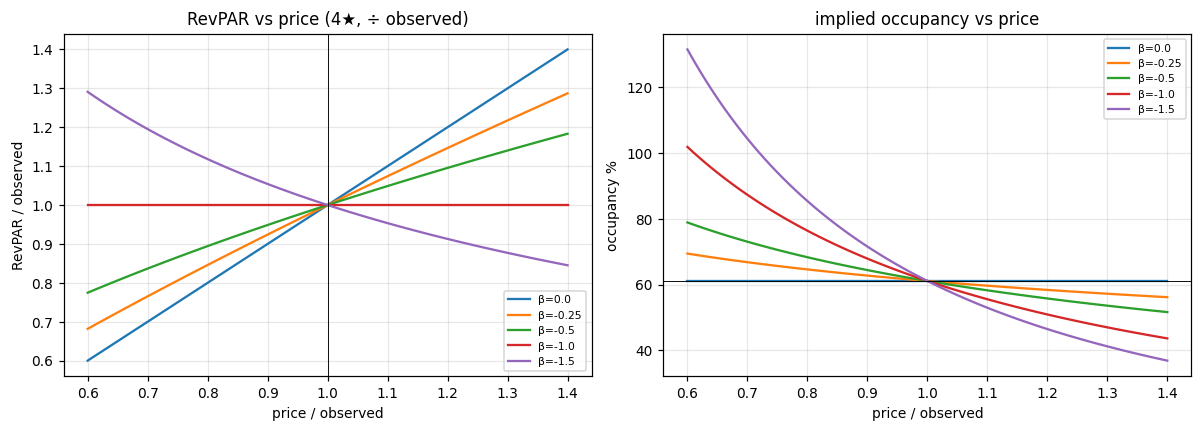

In [2]:
m = df[(df.hotel_category == "stars_4") & (df.split == "test")]
p0, q0 = m["average_rate"].median(), m["room_occupancy"].median() / 100
mult = np.linspace(0.6, 1.4, 81)
i1 = int(np.argmin(np.abs(mult - 1)))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for b in C.BETA_SCENARIOS + [-1.5]:
    rev = (p0 * mult) * (q0 * mult ** b)
    ax[0].plot(mult, rev / rev[i1], label=f"β={b}")
    ax[1].plot(mult, q0 * mult ** b * 100, label=f"β={b}")
ax[0].axvline(1, color="k", lw=.6); ax[0].set_title("RevPAR vs price (4★, ÷ observed)")
ax[0].set_xlabel("price / observed"); ax[0].set_ylabel("RevPAR / observed"); ax[0].legend(fontsize=7)
ax[1].axhline(q0 * 100, color="k", lw=.6); ax[1].set_title("implied occupancy vs price")
ax[1].set_xlabel("price / observed"); ax[1].set_ylabel("occupancy %"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_revenue_curves.png")
LOG.log("figure", "07_revenue_curves.png")
LOG.log("degeneracy", "|β|<1 → RevPAR monotone in P",
        detail="no interior optimum without marginal cost → compare repricing rules, not a point")
plt.show()

## 2 · Worked example — 4★, test window (2024-01 … 2026-05)

τ = 5%, δ = 5% for illustration (notebook 08 selects them on validation).

In [3]:
cat = "stars_4"
s = df[df.hotel_category == cat].sort_values("date")
train = s[s.split == "train"]
occ_norm = PL.seasonal_occ_norm(train)
tgt = EV.target_real_rate(s)
pols = [PL.policy0_frozen(), PL.policy1_monthly_cpi(),
        PL.policy2_threshold(0.05), PL.policy3_threshold_occ(0.05, 0.05)]
paths = {p.name: PL.simulate(p, s, C.TEST_SEGMENT, occ_norm=occ_norm, anchor_real=tgt)
         for p in pols}
paths["observed"] = PL.observed_path(s, C.TEST_SEGMENT)

rows = []
for beta in C.BETA_SCENARIOS:
    for name, pth in paths.items():
        sc = EV.score(pth, beta=beta, target_real=tgt)
        rows.append(dict(policy=name, beta=beta, n_reprice=sc["n_reprice"],
                         real_dev_mean_pct=round(sc["real_dev_mean_pct"], 1),
                         real_dev_min_pct=round(sc["real_dev_min_pct"], 1),
                         real_P_cv_pct=round(sc["real_P_cv_pct"], 1),
                         mean_occ=round(sc["mean_occ"], 1),
                         revpar_vs_obs_pct=round(sc["revpar_vs_obs_pct"], 1)))
ex = pd.DataFrame(rows)
ex.to_csv(C.OUT_TAB / "table_policy_example.csv", index=False)
LOG.log("write", "table_policy_example.csv", len(ex))
ex[ex.beta == -0.5].set_index("policy")

  [07_policies] write                  table_policy_example.csv               20  


,beta,n_reprice,real_dev_mean_pct,real_dev_min_pct,real_P_cv_pct,mean_occ,revpar_vs_obs_pct
policy,,,,,,,
P0_frozen,-0.5,1,-53.5,-70.2,27.4,88.8,-32.4
P1_monthly_cpi,-0.5,25,-4.4,-16.4,3.8,60.6,1.0
P2_tau5,-0.5,13,-5.7,-16.4,3.6,61.0,0.3
P3_tau5_d5,-0.5,13,-6.7,-16.4,4.3,61.3,-0.2
observed,-0.5,25,-5.1,-17.3,11.3,60.7,0.0


## 3 · Illustrative price and real-price paths

  [07_policies] figure                 07_policy_paths_4star.png                  


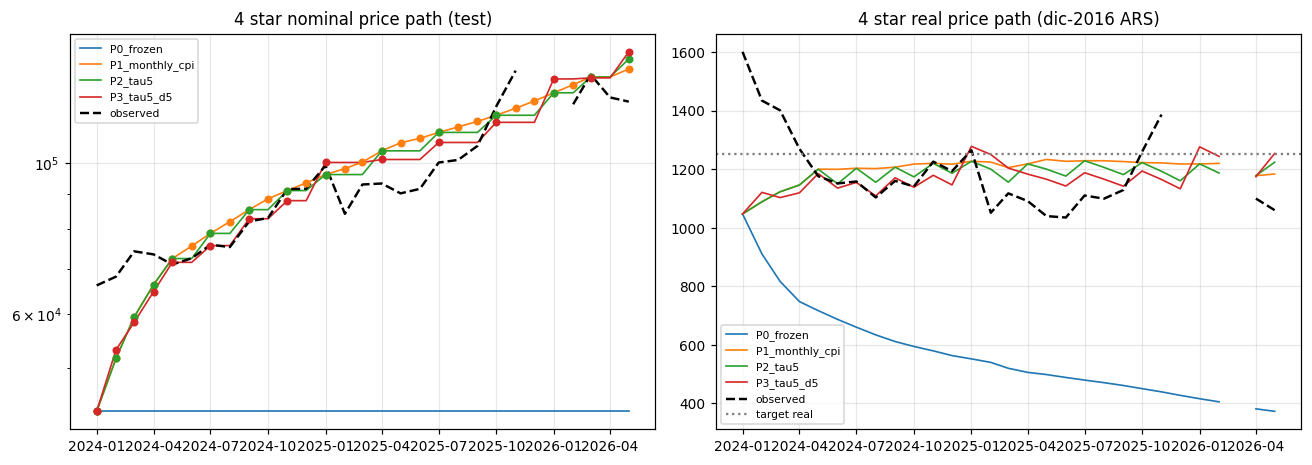

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for name, pth in paths.items():
    st = "k--" if name == "observed" else "-"
    lw = 1.6 if name == "observed" else 1.1
    ax[0].plot(pth.date, pth.P, st, lw=lw, label=name)
    ax[1].plot(pth.date, pth.real_P, st, lw=lw, label=name)
    if name.startswith("P") and "reprice" in pth:
        rp = pth[pth.reprice]
        ax[0].scatter(rp.date, rp.P, s=18, zorder=4)
ax[0].set_yscale("log"); ax[0].set_title(f"{LAB[cat]} nominal price path (test)"); ax[0].legend(fontsize=7)
ax[1].axhline(tgt, color="0.5", ls=":", label="target real")
ax[1].set_title(f"{LAB[cat]} real price path (dic-2016 ARS)"); ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_policy_paths_4star.png")
LOG.log("figure", "07_policy_paths_4star.png"); plt.show()

In [5]:
LOG.flush()
print("07 complete.")

07 complete.


---
<a id='nb08'></a>
# 2 · [nb08] 08 · Threshold optimisation & out-of-sample backtest  (Parts 5 & 6)
---

# 08 · Threshold optimisation & out-of-sample backtest  (Parts 5 & 6)

**Part 5.** For τ ∈ {1,2,3,4,5,6,7,8,10}% simulate Policy 2 over a **selection
window (2022–2023)** that excludes the test period, and record repricing
events, real-price deviation / stability, occupancy and revenue. Trace the
**repricing frontier** (frequency vs real-price deviation), locate its **knee**,
and run an explicit `Objective = Revenue − λ·N_reprice·mean_revenue` sweep.
The efficient τ is *derived*, not assumed to be 5%.

**Part 6.** Fit seasonal occupancy norms + the real-rate target on **train**
(2018-19 + 2022). Freeze τ* (the knee) and δ* from the selection window.
Evaluate on the **untouched test** window (2024-01 … 2026-05) across β
scenarios. No look-ahead: every month-t price uses CPI / occupancy ≤ t−1.
COVID 2020-21 is discussed separately (star-tier rates are missing then).

**Output** `table5_threshold_sim.csv`, `table6_out_of_sample.csv`,
`pareto_frontier.csv`, `lambda_sweep.csv`, `outputs/figures/08_*.png`.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog
import policies as PL
import pricing_eval as EV

LOG = AuditLog("08_backtest")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS).rename(columns={"infl_mom_gba_frac": "infl_mom"})
CATS = C.PRESENT_CATEGORIES
LAB = C.CATEGORY_LABELS
SELECT = ("2022-01-01", "2023-12-01")      # for τ*, δ*  (no test data)
BETA0 = -0.5

prep = {c: dict(s=df[df.hotel_category == c].sort_values("date"),
                occ_norm=PL.seasonal_occ_norm(df[(df.hotel_category == c) & (df.split == "train")]),
                tgt=EV.target_real_rate(df[df.hotel_category == c])) for c in CATS}
LOG.log("prep", "train seasonals + target real",
        detail={k: round(v["tgt"], 0) for k, v in prep.items()})


def sim(cat, pol, window):
    p = prep[cat]
    return PL.simulate(pol, p["s"], window, occ_norm=p["occ_norm"], anchor_real=p["tgt"])


def pooled(pol, window, beta=BETA0):
    return pd.DataFrame([EV.score(sim(c, pol, window), beta, prep[c]["tgt"]) for c in CATS])


def pooled_obs(window, beta=BETA0):
    return pd.DataFrame([EV.score(PL.observed_path(prep[c]["s"], window), beta, prep[c]["tgt"])
                         for c in CATS])

  [08_backtest] prep                   train seasonals + target real              {'stars_1_2': 552.0, 'stars_3': 775.0, 'stars_4': 1252.0, 'stars_5': 3388.0, 'total_composite': 1549.0}


## Part 5 · Threshold simulation on the selection window (Table 5, β = −0.5)

In [7]:
def summarise(per, policy, tau=np.nan):
    return dict(policy=policy, tau_pct=tau,
               reprice_events=per.n_reprice.mean(), reprice_rate=per.reprice_rate.mean(),
               real_dev_mean_pct=per.real_dev_mean_pct.mean(),
               real_dev_min_pct=per.real_dev_min_pct.mean(),
               mean_abs_real_dev_pct=per.mean_abs_real_dev_pct.mean(),
               real_P_cv_pct=per.real_P_cv_pct.mean(),
               months_5pct_below=per.months_5pct_below_target.mean(),
               mean_occ=per.mean_occ.mean(),
               revpar_vs_obs_pct=per.revpar_vs_obs_pct.mean(),
               revpar_cv_pct=per.revpar_cv_pct.mean())


rows = [summarise(pooled(PL.policy2_threshold(t), SELECT), f"P2 τ={t*100:g}%", t*100)
        for t in C.THRESHOLD_GRID]
rows += [summarise(pooled(PL.policy0_frozen(), SELECT), "P0 frozen"),
         summarise(pooled(PL.policy1_monthly_cpi(), SELECT), "P1 monthly CPI"),
         summarise(pooled_obs(SELECT), "observed")]
tab5 = pd.DataFrame(rows).set_index("policy")
tab5.to_csv(C.OUT_TAB / "table5_threshold_sim.csv")
LOG.log("write", "table5_threshold_sim.csv", len(tab5))
tab5.round(2)

  [08_backtest] write                  table5_threshold_sim.csv               12  


,tau_pct,reprice_events,reprice_rate,real_dev_mean_pct,real_dev_min_pct,mean_abs_real_dev_pct,real_P_cv_pct,months_5pct_below,mean_occ,revpar_vs_obs_pct,revpar_cv_pct
policy,,,,,,,,,,,
P2 τ=1%,1.0,21.6,1.00,-7.91,-26.21,7.91,5.06,18.6,67.77,-10.09,59.06
P2 τ=2%,2.0,21.6,1.00,-7.91,-26.21,7.91,5.06,18.6,67.77,-10.09,59.06
P2 τ=3%,3.0,21.6,1.00,-7.91,-26.21,7.91,5.06,18.6,67.77,-10.09,59.06
P2 τ=4%,4.0,21.0,0.98,-8.00,-26.21,8.00,5.04,19.2,67.79,-10.10,59.09
P2 τ=5%,5.0,19.2,0.90,-8.32,-26.21,8.32,5.02,19.2,67.90,-10.19,59.21
P2 τ=6%,6.0,17.2,0.80,-8.85,-26.21,8.85,5.07,19.2,68.10,-10.45,59.34
P2 τ=7%,7.0,14.8,0.70,-9.47,-26.21,9.47,5.15,20.2,68.35,-10.67,59.57
P2 τ=8%,8.0,13.0,0.61,-10.07,-26.21,10.07,5.61,19.6,68.57,-10.96,59.77
P2 τ=10%,10.0,12.0,0.56,-10.49,-26.21,10.49,5.86,20.8,68.78,-11.33,59.14


## The repricing frontier & its knee

As τ rises, repricing events fall (good) and |real-price deviation| rises (bad)
— a strictly monotone trade-off, so *every* τ is technically Pareto-efficient.
The useful quantity is the **knee**: normalise both axes to [0,1] over the grid
and take the τ closest to the ideal (fewest reprices, smallest deviation)
corner. We also report the τ that roughly halves the observed repricing count.

  [08_backtest] frontier_knee          τ                                          knee τ*=6%; τ to halve observed reprices≈10%


  [08_backtest] figure                 08_chart7_frontier.png                     


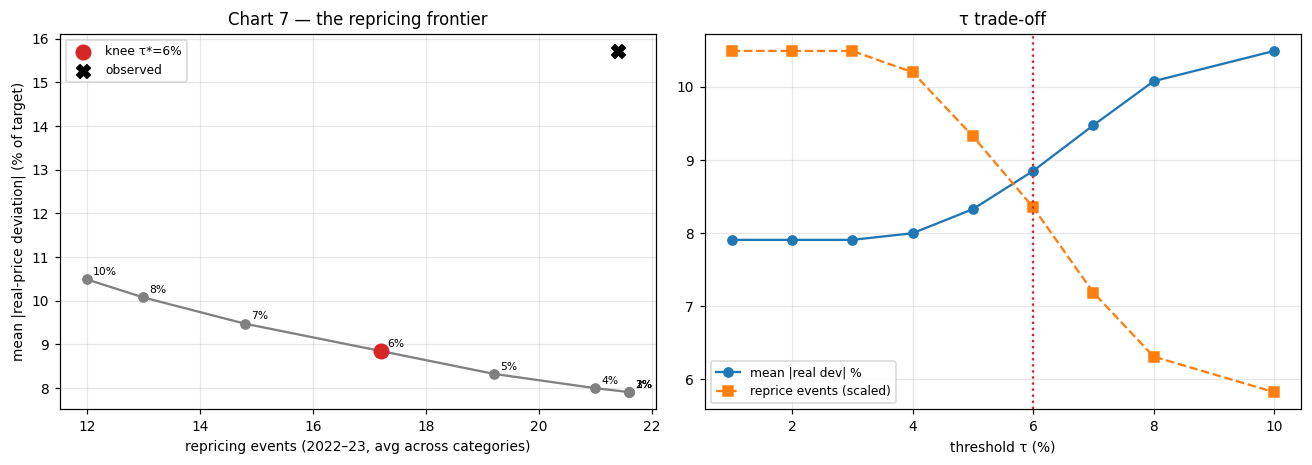

In [8]:
fr = tab5[tab5.tau_pct.notna()].reset_index()
x = fr.reprice_events.to_numpy(); y = fr.mean_abs_real_dev_pct.to_numpy()
xn = (x - x.min()) / (x.max() - x.min())
yn = (y - y.min()) / (y.max() - y.min())
fr["dist_to_ideal"] = np.hypot(xn, yn)
tau_knee = float(fr.loc[fr.dist_to_ideal.idxmin(), "tau_pct"]) / 100
obsN = pooled_obs(SELECT).n_reprice.mean()
tau_half = float(fr.loc[(fr.reprice_events <= obsN / 2).idxmax()
                        if (fr.reprice_events <= obsN / 2).any() else fr.index[-1], "tau_pct"]) / 100
fr["pareto"] = True
fr.to_csv(C.OUT_TAB / "pareto_frontier.csv", index=False)
LOG.log("frontier_knee", "τ", detail=f"knee τ*={tau_knee:.0%}; τ to halve observed reprices≈{tau_half:.0%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(x, y, "o-", color="0.5")
for _, r in fr.iterrows():
    ax[0].annotate(f"{r.tau_pct:.0f}%", (r.reprice_events, r.mean_abs_real_dev_pct),
                   fontsize=7, xytext=(4, 3), textcoords="offset points")
kr = fr[fr.tau_pct == tau_knee * 100]
ax[0].scatter(kr.reprice_events, kr.mean_abs_real_dev_pct, color="tab:red", s=90, zorder=5,
              label=f"knee τ*={tau_knee:.0%}")
o = pooled_obs(SELECT)
ax[0].scatter(o.n_reprice.mean(), o.mean_abs_real_dev_pct.mean(), color="k", marker="X",
              s=80, label="observed")
ax[0].set_xlabel("repricing events (2022–23, avg across categories)")
ax[0].set_ylabel("mean |real-price deviation| (% of target)")
ax[0].set_title("Chart 7 — the repricing frontier"); ax[0].legend(fontsize=8)
ax[1].plot(fr.tau_pct, fr.mean_abs_real_dev_pct, "o-", label="mean |real dev| %")
ax[1].plot(fr.tau_pct, fr.reprice_events / fr.reprice_events.max() * fr.mean_abs_real_dev_pct.max(),
           "s--", label="reprice events (scaled)")
ax[1].axvline(tau_knee * 100, color="tab:red", ls=":")
ax[1].set_xlabel("threshold τ (%)"); ax[1].set_title("τ trade-off"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_chart7_frontier.png")
LOG.log("figure", "08_chart7_frontier.png"); plt.show()

## λ-objective sweep — what repricing penalty would justify each τ

In [9]:
lam_rows = []
for lam in C.LAMBDA_GRID:
    best = max(C.THRESHOLD_GRID, key=lambda t: np.mean(
        [EV.objective(r, lam) for _, r in pooled(PL.policy2_threshold(t), SELECT).iterrows()]))
    lam_rows.append(dict(lam=lam, best_tau_pct=best * 100))
lam_sweep = pd.DataFrame(lam_rows)
lam_sweep.to_csv(C.OUT_TAB / "lambda_sweep.csv", index=False)
LOG.log("lambda_sweep", "best τ vs λ", detail=dict(zip(lam_sweep.lam, lam_sweep.best_tau_pct)))
lam_sweep

  [08_backtest] lambda_sweep           best τ vs λ                                {0.0: 1.0, 0.005: 1.0, 0.01: 4.0, 0.02: 5.0, 0.03: 7.000000000000001, 0.05: 8.0, 0.08: 8.0, 0.12: 10.0}


,lam,best_tau_pct
0,0.000,1.0
1,0.005,1.0
2,0.010,4.0
3,0.020,5.0
4,0.030,7.0
5,0.050,8.0
6,0.080,8.0
7,0.120,10.0


## Does the occupancy tilt (Policy 3) help?  δ chosen on the selection window

In [10]:
d_rows = []
for delta in C.OCC_TILT_GRID:
    per = pooled(PL.policy3_threshold_occ(tau_knee, delta), SELECT)
    d_rows.append(dict(delta_pct=delta * 100, reprice_events=per.n_reprice.mean(),
                       mean_abs_real_dev_pct=per.mean_abs_real_dev_pct.mean(),
                       revpar_vs_obs_pct=per.revpar_vs_obs_pct.mean()))
dtab = pd.DataFrame(d_rows)
delta_star = float(dtab.loc[dtab.mean_abs_real_dev_pct.idxmin(), "delta_pct"]) / 100
LOG.log("delta_pick", "δ* (min |real dev| on selection)", detail=f"δ*={delta_star:.0%}")
dtab

  [08_backtest] delta_pick             δ* (min |real dev| on selection)           δ*=8%


,delta_pct,reprice_events,mean_abs_real_dev_pct,revpar_vs_obs_pct
0,0.0,17.2,8.847652,-10.447809
1,2.0,17.2,8.549330,-10.252541
2,3.0,17.2,8.400168,-10.155710
3,5.0,17.2,8.101846,-9.963635
4,8.0,17.2,7.766521,-9.679434


## Part 6 · Out-of-sample — freeze τ*, δ*, evaluate on 2024-01 … 2026-05 (Table 6)

In [11]:
policies = {"P0_frozen": PL.policy0_frozen(), "P1_monthly": PL.policy1_monthly_cpi(),
            f"P2_tau{tau_knee*100:g}": PL.policy2_threshold(tau_knee),
            f"P3_tau{tau_knee*100:g}_d{delta_star*100:g}":
                PL.policy3_threshold_occ(tau_knee, delta_star)}
t6 = []
for beta in C.BETA_SCENARIOS:
    for nm, pol in policies.items():
        t6.append({**summarise(pooled(pol, C.TEST_SEGMENT, beta), nm), "beta": beta})
    t6.append({**summarise(pooled_obs(C.TEST_SEGMENT, beta), "observed"), "beta": beta})
tab6 = pd.DataFrame(t6)[["policy", "beta", "reprice_events", "real_dev_mean_pct",
                         "real_dev_min_pct", "mean_abs_real_dev_pct", "real_P_cv_pct",
                         "months_5pct_below", "mean_occ", "revpar_vs_obs_pct", "revpar_cv_pct"]]
tab6.to_csv(C.OUT_TAB / "table6_out_of_sample.csv", index=False)
LOG.log("write", "table6_out_of_sample.csv", len(tab6))
tab6[tab6.beta == BETA0].round(2).set_index("policy")

  [08_backtest] write                  table6_out_of_sample.csv               20  


,beta,reprice_events,real_dev_mean_pct,real_dev_min_pct,mean_abs_real_dev_pct,real_P_cv_pct,months_5pct_below,mean_occ,revpar_vs_obs_pct,revpar_cv_pct
policy,,,,,,,,,,
P0_frozen,-0.5,1.0,-53.48,-70.19,53.48,27.44,26.0,84.14,-32.37,18.97
P1_monthly,-0.5,25.0,-4.51,-16.35,4.51,3.87,6.2,57.61,0.69,28.53
P2_tau6,-0.5,13.8,-5.88,-16.35,5.88,3.70,14.2,58.00,0.00,28.75
P3_tau6_d8,-0.5,13.8,-7.88,-16.35,8.23,4.91,20.2,58.64,-1.04,29.11
observed,-0.5,25.2,-4.51,-23.90,11.21,13.25,14.8,57.58,0.00,28.33


## Chart 8 — backtest: dynamic repricing vs mechanical CPI indexing (4★, test)

  [08_backtest] figure                 08_chart8_backtest.png                     


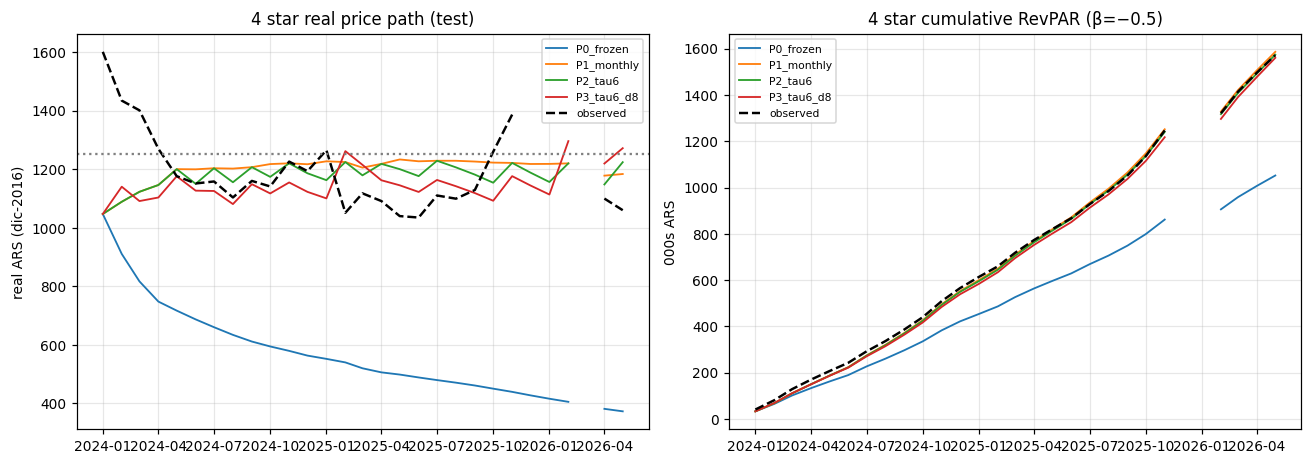

In [12]:
cat = "stars_4"; p = prep[cat]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for nm, pol in policies.items():
    pth = sim(cat, pol, C.TEST_SEGMENT); sc = EV.counterfactual(pth, BETA0)
    ax[0].plot(pth.date, pth.real_P, lw=1.2, label=nm)
    ax[1].plot(pth.date, sc.revpar.cumsum() / 1e3, lw=1.2, label=nm)
ob = PL.observed_path(p["s"], C.TEST_SEGMENT); sco = EV.counterfactual(ob, BETA0)
ax[0].plot(ob.date, ob.real_P, "k--", lw=1.6, label="observed")
ax[1].plot(ob.date, sco.revpar.cumsum() / 1e3, "k--", lw=1.6, label="observed")
ax[0].axhline(p["tgt"], color="0.5", ls=":")
ax[0].set_title(f"{LAB[cat]} real price path (test)"); ax[0].set_ylabel("real ARS (dic-2016)")
ax[0].legend(fontsize=7)
ax[1].set_title(f"{LAB[cat]} cumulative RevPAR (β=−0.5)"); ax[1].set_ylabel("000s ARS")
ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_chart8_backtest.png")
LOG.log("figure", "08_chart8_backtest.png"); plt.show()

## Frontier robustness — does its shape hold out-of-sample?

  [08_backtest] figure                 08_frontier_robustness.png                 


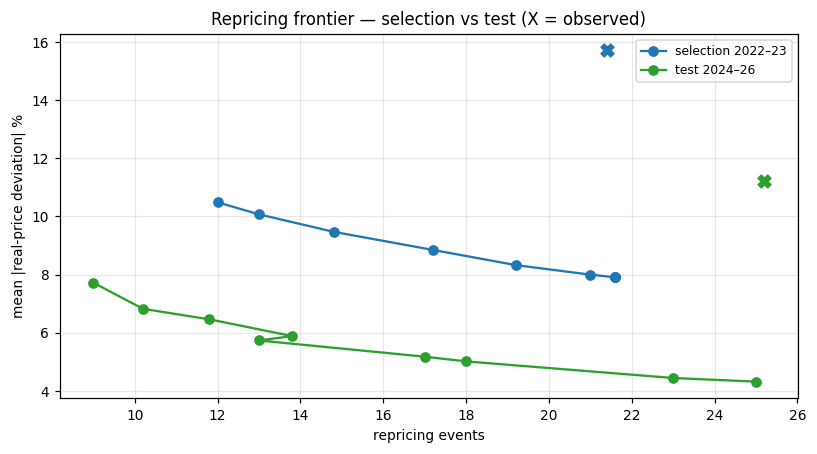

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for win, nm, c in [(SELECT, "selection 2022–23", "tab:blue"),
                   (C.TEST_SEGMENT, "test 2024–26", "tab:green")]:
    xs, ys = [], []
    for t in C.THRESHOLD_GRID:
        per = pooled(PL.policy2_threshold(t), win)
        xs.append(per.n_reprice.mean()); ys.append(per.mean_abs_real_dev_pct.mean())
    ax.plot(xs, ys, "o-", color=c, label=nm)
    o = pooled_obs(win)
    ax.scatter(o.n_reprice.mean(), o.mean_abs_real_dev_pct.mean(), color=c, marker="X", s=70)
ax.set_xlabel("repricing events"); ax.set_ylabel("mean |real-price deviation| %")
ax.set_title("Repricing frontier — selection vs test (X = observed)")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "08_frontier_robustness.png")
LOG.log("figure", "08_frontier_robustness.png"); plt.show()

## COVID stress test — run the recommended rule through the demand collapse

The category rate series are `///` for **22 of the 24 months** of 2020-01 …
2021-12, so no *price-based* quantity can be re-estimated over COVID. What we
**can** do is simulate the policies: CPI is published every month
(~3%/mo, price-frozen), and `total_hoteleros` **occupancy** survives for 17/24
months (the protocol-limited reopening). We anchor to the pre-COVID composite
real-rate target and ask: through a demand collapse, does the τ\* ≈ 6% rule
misbehave? (There is no "observed" rate to beat here — the point is robustness,
not a horse race.)

In [14]:
CW = ("2020-01-01", "2021-12-01")
th = df[df.hotel_category == "total_hoteleros"].sort_values("date").copy()
tgt_c = EV.target_real_rate(prep[C.COMPOSITE_TOTAL]["s"])          # 2018-19 composite real rate
seed_cpi = th.loc[th.date < CW[0], "cpi_gba"].iloc[-1]
th["average_rate"] = np.where(th["date"] == pd.Timestamp(CW[0]),
                              tgt_c * seed_cpi / 100, np.nan)       # single seed so simulate() can anchor
occ_norm_c = prep[C.COMPOSITE_TOTAL]["occ_norm"]
pi_cov = th[(th.date >= CW[0]) & (th.date <= CW[1])]["infl_mom_gba"].mean()
occ_18_19 = df[(df.hotel_category == "total_hoteleros") &
               (df.date >= "2018-01-01") & (df.date <= "2019-12-01")]["room_occupancy"].mean()
occ_cov = th[(th.date >= CW[0]) & (th.date <= CW[1])]["room_occupancy"].mean()

cov_rows = []
for nm, pol in [("P0 frozen", PL.policy0_frozen()),
                ("P1 monthly CPI", PL.policy1_monthly_cpi()),
                (f"P2 τ={tau_knee*100:g}%", PL.policy2_threshold(tau_knee))]:
    path = PL.simulate(pol, th, CW, occ_norm=occ_norm_c, anchor_real=tgt_c)
    d = path.dropna(subset=["real_P"])
    dev = d["real_P"] / tgt_c - 1                       # no observed rate -> score vs target directly
    revpar_real = (d["P"] * d["occ_obs"] / 100 / d["cpi"] * 100)   # real RevPAR where occ exists
    cov_rows.append(dict(
        policy=nm, n_reprice=int(d["reprice"].sum()),
        real_dev_mean_pct=round(dev.mean() * 100, 1),
        real_dev_min_pct=round(dev.min() * 100, 1),
        real_revpar_total=round(revpar_real.sum(), 0),
        months_occ_obs=int(d["occ_obs"].notna().sum())))
cov_tab = pd.DataFrame(cov_rows)
cov_tab.to_csv(C.OUT_TAB / "covid_stress.csv", index=False)
LOG.log("covid_stress", "policies through 2020-21 (total_hoteleros occ + CPI)",
        detail=f"CPI ~{pi_cov:.1f}%/mo; occupancy {occ_18_19:.0f}% -> {occ_cov:.0f}%; "
               + "; ".join(f"{r['policy']}: {r['n_reprice']:.0f} reprices, "
                           f"real dev {r['real_dev_mean_pct']:+.0f}%" for r in cov_rows))
cov_tab

  [08_backtest] covid_stress           policies through 2020-21 (total_hoteleros occ + CPI)           CPI ~3.0%/mo; occupancy 62% -> 27%; P0 frozen: 1 reprices, real dev -27%; P1 monthly CPI: 24 reprices, real dev -3%; P2 τ=6%: 10 reprices, real dev -5%


,policy,n_reprice,real_dev_mean_pct,real_dev_min_pct,real_revpar_total,months_occ_obs
0,P0 frozen,1,-26.7,-50.8,5014.0,17
1,P1 monthly CPI,24,-2.9,-4.9,6814.0,17
2,P2 τ=6%,10,-4.9,-8.9,6690.0,17


**Reading.** Through the collapse the frozen price (P0) loses ~half its real
value (inflation kept running at ~3%/mo behind a price freeze); the τ ≈ 6% rule
fires every ~2 months and holds the real price near target, exactly as in
normal times — it does **not** break. What it also does **not** do is *cut*
the price in response to the demand collapse: the rule is inflation-state-
dependent, not demand-state-dependent. Given that demand is inelastic
(notebook 06) a mechanical cut would not have recovered occupancy, but a hotel
might still want a discretionary promotional cut for cash-flow reasons the
model does not capture. **The recommended policy is validated for
inflation regimes, not for demand-collapse regimes** — see notebook 10.

In [15]:
LOG.flush()
print(f"08 complete. τ* (knee) = {tau_knee:.0%}, δ* = {delta_star:.0%}")

08 complete. τ* (knee) = 6%, δ* = 8%
